In [1]:
#apakah keterlambatan mempengaruhi kepuasan??
import pandas as pd 

#1. Load the dataset and print the shape, column names, and first few rows of the dataframe.
df = pd.read_csv('../data/olist_classified_public_dataset.csv')

print(df.shape)
print(df.columns.tolist())
print(df.head())


(3584, 34)
['Unnamed: 0', 'id', 'order_status', 'order_products_value', 'order_freight_value', 'order_items_qty', 'order_sellers_qty', 'order_purchase_timestamp', 'order_aproved_at', 'order_estimated_delivery_date', 'order_delivered_customer_date', 'customer_city', 'customer_state', 'customer_zip_code_prefix', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp', 'votes_before_estimate', 'votes_delayed', 'votes_low_quality', 'votes_return', 'votes_not_as_anounced', 'votes_partial_delivery', 'votes_other_delivery', 'votes_other_order', 'votes_satisfied', 'most_voted_subclass', 'most_voted_class']
   Unnamed: 0  id order_status  order_products_value  order_freight_value  \
0           0   1    delivered                 89.99                14.38   
1           1   2    delivered                 69.00                15.23   
2  

In [2]:
#2 Data Exploration
#Lihat hanya kolom yang relevan 

kolom_relevan = [
    'order_purchase_timestamp',
    'order_aproved_at',
    'order_estimated_delivery_date',
    'order_delivered_customer_date',
    'order_items_qty',
    'customer_city',
    'review_score',
    'most_voted_class',
    'most_voted_subclass'
]

df_relevan = df[kolom_relevan]  
print(df_relevan.shape)
df_relevan.head

(3584, 9)


<bound method NDFrame.head of         order_purchase_timestamp            order_aproved_at  \
0     2017-08-30 11:41:01.000000  2017-08-30 11:55:08.970352   
1     2017-09-26 09:13:36.000000  2017-09-26 09:28:10.922048   
2     2018-01-15 15:50:42.000000  2018-01-17 07:29:56.419769   
3     2018-02-04 11:16:42.000000  2018-02-06 05:31:50.990164   
4     2017-12-07 11:58:42.000000  2017-12-08 02:36:49.587515   
...                          ...                         ...   
3579  2017-11-27 09:28:50.000000  2017-11-27 09:38:27.474464   
3580  2017-05-11 12:29:55.000000  2017-05-11 13:05:49.204273   
3581  2017-05-21 20:15:25.000000  2017-05-23 03:42:32.806938   
3582  2017-09-29 16:05:14.000000  2017-09-29 16:27:57.145051   
3583  2017-08-21 07:31:40.000000  2017-08-21 07:44:27.614744   

     order_estimated_delivery_date order_delivered_customer_date  \
0       2017-09-21 00:00:00.000000    2017-09-08 20:35:27.276847   
1       2017-10-24 00:00:00.000000    2017-09-29 21:13:04.984841 

In [3]:
df_relevan.info()

<class 'pandas.DataFrame'>
RangeIndex: 3584 entries, 0 to 3583
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_purchase_timestamp       3584 non-null   str  
 1   order_aproved_at               3584 non-null   str  
 2   order_estimated_delivery_date  3584 non-null   str  
 3   order_delivered_customer_date  3467 non-null   str  
 4   order_items_qty                3584 non-null   int64
 5   customer_city                  3584 non-null   str  
 6   review_score                   3584 non-null   int64
 7   most_voted_class               3413 non-null   str  
 8   most_voted_subclass            3413 non-null   str  
dtypes: int64(2), str(7)
memory usage: 758.1 KB


In [4]:
print(df['order_status'].value_counts())

order_status
delivered     3467
shipped         48
canceled        25
invoiced        24
processing      20
Name: count, dtype: int64


In [5]:
#Cek order yang mempunyai order_estimated_delvery_date, order_delivered_customer_date, dan review_score
df.groupby('order_status')['order_delivered_customer_date'].apply(lambda x: x.isnull().sum())

order_status
canceled      25
delivered      0
invoiced      24
processing    20
shipped       48
Name: order_delivered_customer_date, dtype: int64

In [6]:
#3. Filter data
df_delivered = df[df['order_status'] == 'delivered'].copy()
print(df_delivered.shape)

(3467, 34)


In [7]:
#menambahkan order_status ke kolom relevan dan membuat dataframe final
kolom_relevan.append('order_status')
df_clean = df_delivered[kolom_relevan].copy()
print(df_clean.shape)
df_clean.info()

(3467, 10)
<class 'pandas.DataFrame'>
Index: 3467 entries, 0 to 3583
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_purchase_timestamp       3467 non-null   str  
 1   order_aproved_at               3467 non-null   str  
 2   order_estimated_delivery_date  3467 non-null   str  
 3   order_delivered_customer_date  3467 non-null   str  
 4   order_items_qty                3467 non-null   int64
 5   customer_city                  3467 non-null   str  
 6   review_score                   3467 non-null   int64
 7   most_voted_class               3303 non-null   str  
 8   most_voted_subclass            3303 non-null   str  
 9   order_status                   3467 non-null   str  
dtypes: int64(2), str(8)
memory usage: 823.1 KB


In [8]:
print(df_clean['most_voted_class'].value_counts())
print(df_clean['most_voted_subclass'].value_counts())

most_voted_class
satisfeito_com_pedido     1976
problemas_de_entrega       868
problemas_de_qualidade     459
Name: count, dtype: int64
most_voted_subclass
satisfeito                1486
antes_prazo                490
entrega_parcial            397
atrasado                   366
diferente_do_anunciado     163
baixa_qualidade            146
devolucao                  127
outro_entrega              105
outro_pedido                23
Name: count, dtype: int64


In [9]:
null_voted = df_clean[df_clean['most_voted_class'].isnull()]
print(null_voted['review_score'].value_counts())

review_score
1    57
3    36
5    27
4    25
2    19
Name: count, dtype: int64


In [10]:
print("Distribusi review score KESELURUHAN:")
print(df_clean['review_score'].value_counts())

print("\nDistribusi review score yang NULL most_voted_class:")
print(df_clean[df_clean['most_voted_class'].isnull()]['review_score'].value_counts())

Distribusi review score KESELURUHAN:
review_score
5    1649
1     776
4     512
3     325
2     205
Name: count, dtype: int64

Distribusi review score yang NULL most_voted_class:
review_score
1    57
3    36
5    27
4    25
2    19
Name: count, dtype: int64


In [11]:
#4. Cleaning Data
'''
selisih = order_delivered_customer_date - order_estimated_delivery_date

+ (positif) = TERLAMBAT   → aktual lebih lambat dari estimasi
- (negatif) = LEBIH CEPAT → aktual lebih cepat dari estimasi
0           = TEPAT WAKTU
'''

kolom_tanggal = [
    'order_purchase_timestamp',
    'order_aproved_at',
    'order_estimated_delivery_date',
    'order_delivered_customer_date'
    ]

for kolom in kolom_tanggal:
    df_clean[kolom] = pd.to_datetime(df_clean[kolom])

df_clean.info()

<class 'pandas.DataFrame'>
Index: 3467 entries, 0 to 3583
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_purchase_timestamp       3467 non-null   datetime64[us]
 1   order_aproved_at               3467 non-null   datetime64[us]
 2   order_estimated_delivery_date  3467 non-null   datetime64[us]
 3   order_delivered_customer_date  3467 non-null   datetime64[us]
 4   order_items_qty                3467 non-null   int64         
 5   customer_city                  3467 non-null   str           
 6   review_score                   3467 non-null   int64         
 7   most_voted_class               3303 non-null   str           
 8   most_voted_subclass            3303 non-null   str           
 9   order_status                   3467 non-null   str           
dtypes: datetime64[us](4), int64(2), str(4)
memory usage: 469.3 KB


In [12]:
#Membuat kolom selisih hari
df_clean['delivery_delay_days'] = (
    df_clean['order_delivered_customer_date'] - 
    df_clean['order_estimated_delivery_date']
) .dt.days

print(df_clean['delivery_delay_days'].describe())

count    3467.000000
mean      -10.873666
std        10.946529
min       -71.000000
25%       -16.000000
50%       -12.000000
75%        -7.000000
max       138.000000
Name: delivery_delay_days, dtype: float64


In [13]:
print(df_clean[df_clean['delivery_delay_days'] == df_clean['delivery_delay_days'].max()])

    order_purchase_timestamp           order_aproved_at  \
889      2017-03-29 13:37:49 2017-03-30 06:35:12.665771   
954      2017-04-04 23:21:02 2017-04-04 23:30:19.697915   

    order_estimated_delivery_date order_delivered_customer_date  \
889                    2017-05-04    2017-09-19 18:12:07.625754   
954                    2017-05-04    2017-09-19 13:47:09.916278   

     order_items_qty customer_city  review_score       most_voted_class  \
889                1   Joao Pessoa             2   problemas_de_entrega   
954                1       Valenca             4  satisfeito_com_pedido   

    most_voted_subclass order_status  delivery_delay_days  
889       outro_entrega    delivered                  138  
954          satisfeito    delivered                  138  


In [14]:
print(df_clean[df_clean['delivery_delay_days'] == df_clean['delivery_delay_days'].min()])

    order_purchase_timestamp           order_aproved_at  \
182      2017-05-21 08:01:31 2017-05-22 10:41:28.006054   

    order_estimated_delivery_date order_delivered_customer_date  \
182                    2017-08-23    2017-06-13 06:51:53.836908   

     order_items_qty customer_city  review_score       most_voted_class  \
182                1     Queimados             4  satisfeito_com_pedido   

    most_voted_subclass order_status  delivery_delay_days  
182          satisfeito    delivered                  -71  


In [15]:
print(df_clean.columns.tolist())

['order_purchase_timestamp', 'order_aproved_at', 'order_estimated_delivery_date', 'order_delivered_customer_date', 'order_items_qty', 'customer_city', 'review_score', 'most_voted_class', 'most_voted_subclass', 'order_status', 'delivery_delay_days']


In [16]:
#Drop kolom yang tidak dipakai
df_clean = df_clean.drop(columns=['most_voted_class', 'most_voted_subclass'])
print(df_clean.columns.tolist())

['order_purchase_timestamp', 'order_aproved_at', 'order_estimated_delivery_date', 'order_delivered_customer_date', 'order_items_qty', 'customer_city', 'review_score', 'order_status', 'delivery_delay_days']


## Data Cleaning

### 1. Filter Order Status
Hanya menggunakan order dengan status `delivered` karena:
- Memiliki tanggal aktual pengiriman yang lengkap
- Memungkinkan perhitungan keterlambatan yang akurat
- Status lain (shipped, canceled, dll) tidak memiliki data lengkap untuk analisis

### 2. Konversi Tipe Data Tanggal
Kolom tanggal diubah dari tipe string (str) menjadi datetime agar dapat digunakan untuk menghitung selisih waktu antara tanggal estimasi dan tanggal pengiriman aktual. Jika masih berupa string, perhitungan tanggal tidak dapat dilakukan dengan benar

### 3. Membuat kolom delivery_delay_days
Kolom delivery_delay_days dibuat untuk menghitung selisih hari antara tanggal pengiriman aktual (order_delivered_customer_date) dan tanggal estimasi pengiriman (order_estimated_delivery_date).

Interpretasi nilainya:

Nilai positif = pesanan terlambat
Nilai negatif = pesanan tiba lebih cepat dari estimasi
Nilai 0 = pesanan tiba tepat waktu

Kolom ini membantu melihat berapa hari keterlambatan atau percepatan pengiriman dibandingkan estimasi yang diberikan. 
### 4. Investigasi dan keputusan outlier
Outlier adalah data yang memiliki nilai sangat berbeda dari sebagian besar data lainnya. Investigasi dilakukan untuk mengetahui apakah nilai tersebut merupakan data yang valid atau kesalahan pencatatan, serta untuk melihat dampaknya terhadap hasil analisis.

Ditemukan nilai ekstrem:

Keterlambatan hingga 138 hari
Pengiriman lebih cepat hingga 71 hari

Setelah dilakukan pemeriksaan, kedua nilai tersebut dianggap masih valid sehingga tetap dipertahankan dalam dataset. Namun, keterlambatan 138 hari diberi tanda (flag) sebagai outlier ekstrem agar dapat diperhatikan pada tahap analisis. 
### 5. Drop kolom
Ini menghapus kolom yang tidak digunakan yaitu 'most_voted_class', 'most_voted_subclass' karena kolom ini kurang relevan terhadap business question. Menghapus kolom yang tidak diperlukan membantu membuat dataset lebih sederhana dan fokus pada informasi yang dibutuhkan.

##### Exploratory Data Analysis (EDA)

In [17]:
# Eksplorasi Pertama - Distribusi keterlambatan

import matplotlib.pyplot as plt

#kategorisasi order
def kategorisasi_delay(hari):
    if hari > 0:
        return 'Terlambat'
    elif hari == 0:
        return 'Tepat waktu'
    else:
        return 'Lebih cepat'
    
df_clean['delay_category'] = df_clean['delivery_delay_days'].apply(kategorisasi_delay)
print(df_clean['delay_category'].value_counts())

delay_category
Lebih cepat    3087
Terlambat       339
Tepat waktu      41
Name: count, dtype: int64


In [18]:
df_clean['estimation_window'] = (
    df_clean['order_estimated_delivery_date'] - 
    df_clean['order_purchase_timestamp']
).dt.days

print(df_clean['estimation_window'].describe())

count    3467.000000
mean       24.305163
std         7.459549
min         7.000000
25%        20.000000
50%        24.000000
75%        28.000000
max        93.000000
Name: estimation_window, dtype: float64


In [19]:
df_clean['actual_delivery_time'] = (
    df_clean['order_delivered_customer_date'] -
    df_clean['order_purchase_timestamp']
).dt.days

print(df_clean['actual_delivery_time'].describe())

count    3467.000000
mean       14.042400
std        11.232511
min         0.000000
25%         7.000000
50%        11.000000
75%        18.000000
max       174.000000
Name: actual_delivery_time, dtype: float64


In [20]:
print((df_clean['delivery_delay_days'] + df_clean['estimation_window'] - df_clean['actual_delivery_time']).describe())

count    3467.000000
mean       -0.610903
std         0.487616
min        -1.000000
25%        -1.000000
50%        -1.000000
75%         0.000000
max         0.000000
dtype: float64


In [21]:
sample = df_clean.iloc[0]
print("Purchase:", sample['order_purchase_timestamp'])
print("Estimated:", sample['order_estimated_delivery_date'])
print("Delivered:", sample['order_delivered_customer_date'])
print("delivery_delay_days:", sample['delivery_delay_days'])
print("estimation_window:", sample['estimation_window'])
print("actual_delivery_time:", sample['actual_delivery_time'])

Purchase: 2017-08-30 11:41:01
Estimated: 2017-09-21 00:00:00
Delivered: 2017-09-08 20:35:27.276847
delivery_delay_days: -13
estimation_window: 21
actual_delivery_time: 9


### Catatan: Bug Pembulatan pada .dt.days
Saat mencoba memverifikasi hubungan antara delivery_delay_days, estimation_window, dan 
actual_delivery_time, ditemukan selisih kecil (~0.6 hari) saat ketiganya dijumlahkan secara manual.
Setelah diinvestigasi, ternyata penyebabnya adalah .dt.days yang membulatkan ke arah negatif 
pada nilai timedelta negatif dengan komponen jam.
Kesimpulan: kolom individual (delivery_delay_days, estimation_window, actual_delivery_time) 
tetap akurat, karena masing-masing dihitung langsung dari dua timestamp asli, bukan dari 
penjumlahan kolom lain.

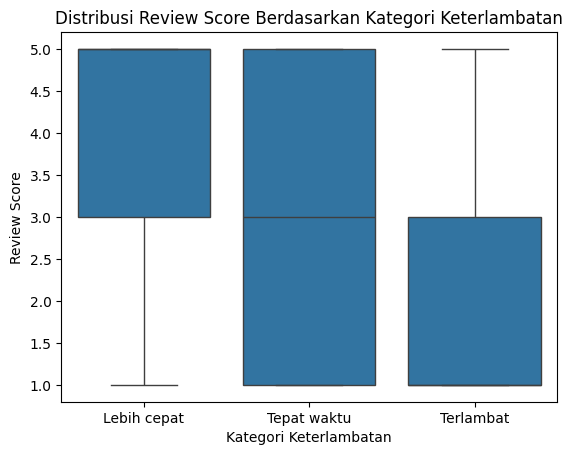

In [22]:
#Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(data=df_clean, x='delay_category', y='review_score')
plt.title('Distribusi Review Score Berdasarkan Kategori Keterlambatan')
plt.xlabel('Kategori Keterlambatan')
plt.ylabel('Review Score')
plt.show()

### Interpretasi Boxplot
Dari boxplot di atas, terlihat bahwa kategori "Lebih cepat" memiliki rentang Q1-Q3 yang lebih tinggi 
(sekitar 3.00- 5.00), menunjukkan customer di kategori ini cenderung memberi rating yang tinggi.
Sebaliknya, kategori "Terlambat" memiliki rentang Q1-Q3 yang lebih rendah (sekitar 1- 3), 
menunjukkan kecenderungan rating yang rendah.
Catatan: kategori "Tepat waktu" hanya memiliki 41 order (1.18% dari total), 
sehingga kesimpulan untuk kategori ini kurang dapat diandalkan.

In [23]:
#Pearson correlation
korelasi = df_clean['delivery_delay_days'].corr(df_clean['review_score'])
print(korelasi)

-0.2523430848512244


In [24]:
#Spearman correlation

korelasi_spearman = df_clean['delivery_delay_days'].corr(df_clean['review_score'], method='spearman')
print(korelasi_spearman)

-0.16864911388418338


### Interpretasi Korelasi
Nilai korelasi Pearson sebesar -0.25 dan Spearman sebesar -0.17 menunjukkan hubungan yang lemah dan sangat lemah
antara keterlambatan dan review score.
Ini berarti keterlambatan tidak menjadi faktor utama yang menentukan kepuasan customer, 
karena kemungkinan ada faktor lain (seperti kualitas produk, harga, dll) yang juga mempengaruhi review score  namun tidak tersedia di dataset ini.

In [25]:
extreme_late = df_clean[df_clean['delivery_delay_days'] > 14]
print(extreme_late.shape)
print(extreme_late['review_score'].describe())

(95, 12)
count    95.000000
mean      1.526316
std       1.109362
min       1.000000
25%       1.000000
50%       1.000000
75%       1.000000
max       5.000000
Name: review_score, dtype: float64


### Investigasi Lanjutan: Mencari Penyebab Keterlambatan Ekstrem
Ditemukan bahwa 95 order (2.74% dari total) mengalami keterlambatan ekstrem (>14 hari), 
dengan: median review score hanya 1, jauh di bawah rata-rata keseluruhan.
Untuk memahami penyebabnya, diuji dua hipotesis berikut.

In [26]:
# Cek apakah estimasi delivery bervariasi per kota, atau seragam
df_clean.groupby('customer_city')['order_estimated_delivery_date'].nunique().describe()

count    879.000000
mean       3.110353
std        9.463531
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max      195.000000
Name: order_estimated_delivery_date, dtype: float64

In [27]:
df_clean.groupby('customer_city')['estimation_window'].agg(['mean', 'std', 'count']).sort_values('count', ascending=False).head(10)


,mean,std,count
customer_city,,,
Sao Paulo,19.654846,6.940097,423
RIO DE JANEIRO,24.052632,5.835889,266
Belo Horizonte,23.129870,5.398223,77
BRASILIA,24.777778,4.688080,72
Salvador,28.573770,4.769553,61
Campinas,17.734694,5.219257,49
Guarulhos,20.204545,6.610701,44
Porto Alegre,28.000000,5.817397,39
Curitiba,22.833333,5.146427,36


In [28]:
# Ambil beberapa order dengan purchase date yang sama, lihat variasi estimated_delivery_date
df_clean['purchase_date_only'] = df_clean['order_purchase_timestamp'].dt.date

sample_date = df_clean['purchase_date_only'].value_counts().index[0]  # tanggal dengan order terbanyak
sample = df_clean[df_clean['purchase_date_only'] == sample_date][['customer_city', 'order_purchase_timestamp', 'order_estimated_delivery_date']]
print(sample)

              customer_city order_purchase_timestamp  \
135            Porto Alegre      2017-11-24 16:59:45   
146          RIO DE JANEIRO      2017-11-24 14:08:46   
199             Nova Iguacu      2017-11-24 13:50:10   
246               Sao Paulo      2017-11-24 18:52:10   
248               Sao Paulo      2017-11-24 09:15:36   
260          RIO DE JANEIRO      2017-11-24 10:38:40   
275               Sao Paulo      2017-11-24 09:32:43   
393          Angra dos Reis      2017-11-24 08:24:53   
408              Parnamirim      2017-11-24 15:43:07   
439                 Ubatuba      2017-11-24 01:24:10   
464               Sao Paulo      2017-11-24 13:06:07   
529          RIO DE JANEIRO      2017-11-24 18:47:14   
547                Curitiba      2017-11-24 08:39:30   
687               Sao Paulo      2017-11-24 09:15:36   
739            Praia Grande      2017-11-24 22:55:16   
855                Ipatinga      2017-11-24 13:20:37   
856                 Guapore      2017-11-24 23:5

### Hipotesis 1: Estimasi delivery seragam berdasarkan tanggal pembelian, bukan kota 

Diduga bahwa order yang dibeli pada hari yang sama akan mendapat tanggal estimasi yang sama, tidak peduli kotanya, kemungkinan karena sistem menggunakan nilai default. 

**Pengujian**: Apakah estimasi delivery bervariasi perkota atau seragam

**Hasil**: `estimation_window` per kota — Sao Paulo 19.65 hari, Salvador 28.57 hari, dst, dan juga temuan dari cek order di tanggal yang sama yang ternyata estimasinya berbeda-beda per kota 

**Kesimpulan**: Hipotesis ini terbantahkan, karena Estimasi delivery nya bervariasi

In [29]:
#Uji apakah order_items_qty berhubungan dengan keterlambatan ekstrem. 
df_clean['is_extreme_late'] = df_clean['delivery_delay_days'] > 14
print(df_clean['is_extreme_late'].value_counts())

is_extreme_late
False    3372
True       95
Name: count, dtype: int64


In [30]:
df_clean.groupby('is_extreme_late')['order_items_qty'].describe()

,count,mean,std,min,25%,50%,75%,max
is_extreme_late,,,,,,,,
False,3372.0,1.102610,0.454549,1.0,1.0,1.0,1.0,8.0
True,95.0,1.073684,0.333967,1.0,1.0,1.0,1.0,3.0


### Hipotesis 2: Order dengan banyak item lebih sering terlambat

Diasumsikan bahwa order dengan banyak item memiliki risiko keterlambatan yang lebih tinggi karena proses pengemasan bisa lebih lama atau melibatkan beberapa seller. Untuk menguji hal ini, dilakukan perbandingan jumlah item per order (`order_items_qty`) antara order yang terlambat ekstrem (>14 hari) dan order normal menggunakan `.groupby()`.

**Hasil:** Rata-rata jumlah item pada order terlambat adalah 1.10, sedangkan pada order normal 1.07. Selain itu, nilai median, Q1, dan Q3 pada kedua kelompok sama-sama 1. Perbedaan yang ditemukan sangat kecil dan tidak menunjukkan pola yang berarti.

**Kesimpulan:** Hipotesis tidak terbukti. Jumlah item dalam order tidak menunjukkan hubungan yang signifikan dengan keterlambatan pengiriman, sehingga perbedaan yang terlihat kemungkinan hanya merupakan variasi acak (noise).


### Kesimpulan & Rekomendasi Bisnis 

###  Kesimpulan

1. **Estimasi vs Realita Pengiriman**: Estimasi dan realita kedatangan barang memiliki selisih yang sangat jauh dengan estimasi rata-rata 24.3 hari, sedangkan realitanya rata-rata 14.04 hari, dan selisih (buffer) ~10 hari. Estimasi yang longgar membuat metrik "on-time delivery" terlihat bagus secara artifisial.
2. **Korelasi Keterlambatan dan Review Score**: Keterlambatan memiliki korelasi dengan review pengguna, hanya saja keterlambatan ini bukan pengaruh utama yang mempengaruhi review score nya tinggi atau rendah
3. **Segmen Keterlambatan Ekstrem**: Ditemukan bahwa 95 order (2.74% dari total) mengalami keterlambatan ekstrem (>14 hari), dengan median review score hanya 1, jauh di bawah rata-rata keseluruhan. Bahkan 75% dari order ini memberikan rating 1 (Q3 = 1, artinya 75% data ≤ 1).
4. **Hipotesis yang Diuji**:
   1. order_items_qty tidak berhubungan dengan keterlambatan ekstrem. Mayoritas order — baik yang terlambat ekstrem maupun normal — sama-sama hanya berisi 1 item. Hipotesis "order dengan banyak item lebih mungkin terlambat" tidak terbukti dari data ini.
   2. Estimasi delivery tidak sama untuk semua order di hari pembelian yang sama. Estimasi tanggal pengirimannya bervariasi, bahkan untuk order yang dibeli di hari yang sama (24 November 2017) sehingga hipotesis terbantahkan

### Rekomendasi Bisnis
   1. Evaluasi ulang estimasi delivery, dengan mempertimbangkan trade-off antara ekspektasi realistis vs risiko "terlambat" yang meningkat
   2. Investigasi lebih dalam ke 95 order ekstrem secara manual/kualitatif, karena data kuantitatif yang ada tidak cukup menjelaskan penyebabnya
   3. Kumpulkan data tracking/checkpoint pengiriman untuk analisis akar masalah yang lebih dalam di masa depan 

### Limitasi

1. Dataset ini tidak memiliki variabel yang secara langsung merepresentasikan kualitas produk, kesesuaian produk dengan deskripsi, kualitas kemasan, maupun persepsi harga. Faktor-faktor tersebut kemungkinan memiliki pengaruh yang lebih besar terhadap review score pelanggan, namun tidak dapat dianalisis pada penelitian ini.
2. Variabel lokasi pelanggan (`customer_city`) tersedia dalam dataset, tetapi belum dianalisis lebih lanjut. Oleh karena itu, belum dapat disimpulkan apakah faktor geografis atau wilayah tertentu memiliki hubungan dengan keterlambatan pengiriman maupun tingkat kepuasan pelanggan.
3. Jumlah sampel pada kategori Tepat waktu relatif kecil (41 order atau sekitar 1% dari total data), sehingga hasil analisis pada kelompok ini perlu diinterpretasikan dengan hati-hati.